# Quantum error correction with **tsim** — a Stim-API walkthrough

*Directory 9 · the tsim counterpart of the ITensor surface-code series.*

The notebooks in directories 1–7 taught rotated-planar surface-code QEC on an
**exact matrix-product-state engine** (ITensor, Julia): encode one logical qubit
→ build an MWPM decoder → two logical qubits and Clifford entanglement → magic
states and a logical $T$ → lattice surgery → a real-time sliding-window decoder →
a stochastic noise model with a Monte-Carlo $p_L$ at $d=3$.

That engine is *exact*: it propagates the full physical quantum state. Its
strength — every amplitude, any observable, no sampling noise — is also its wall.
The state's memory grows with entanglement, so the ITensor notebooks live at
$d=3$ with a handful of patches, and notebook 7 could show $p_L$ rising with $p$
but **could not cross two distance curves** ($d=3$ vs $d=5$) to see a threshold.

This notebook rebuilds the same arc on a completely different engine —
**tsim** (`bloqade-tsim`, QuEra). tsim mirrors the **Stim** API and samples
circuits by a **ZX stabiliser-rank decomposition**, so, unlike Stim, it handles
the non-Clifford $T$ gate *natively*. It does not store the state; it **samples
shots**, and decodes them with **PyMatching** (MWPM). Where the MPS gives you one
exact expectation, tsim gives you a million cheap shots — exactly what a
threshold study needs.

**What this notebook does**

1. §1 encode and measure one logical qubit (a rotated-code *memory*);
2. §2 decode it with a detector-error-model + PyMatching;
3. §3 entangle two logical qubits with a transversal CNOT → a logical Bell state;
4. §4 add the non-Clifford $T$ two ways — the bare-qubit shortcut and a proper
   magic-state injection — building the magic-Bell $H\cdot T\cdot\mathrm{CNOT}$;
5. §5 contrast tsim's whole-circuit decoding with notebook 6's sliding window;
6. §6 sweep noise and **cross the $d=3$, $d=5$, $d=7$ threshold curves** — the
   plot the MPS engine could not produce;
7. §7 recap, and hand off to the head-to-head comparison in
   `example_tsim_vs_itensor.ipynb`.

| | ITensor MPS engine (notebooks 1–7) | tsim (this notebook) |
|---|---|---|
| Represents | the **exact physical state** (MPS) | a **sample stream** of shots |
| Readout | exact non-collapsing $\langle O\rangle$ | Monte-Carlo estimate from shots |
| Non-Clifford $T$ | exact operator on the state | native, cost $\sim 2^{\#T}$ |
| Cost driver | entanglement / bond dimension | Clifford count (linear) + $\#T$ |
| Natural home | small $d$, deep logic, *exactness* | large $d$, many shots, *thresholds* |


## §0 — Why tsim: the Stim API plus one non-Clifford trick

[Stim](https://github.com/quantumlib/Stim) is the standard fast stabiliser
simulator for QEC: it samples Clifford circuits in time near-linear in the number
of gates. Its limit is fundamental — a pure stabiliser simulator cannot represent
a $T$ gate.

**tsim** keeps Stim's circuit language and sampler API but represents the state
as a **stabiliser-rank decomposition** (a ZX-calculus sum of stabiliser terms).
A Clifford gate acts in linear time as usual; each **$T$ gate** at most *doubles*
the number of terms. So tsim samples in time linear in the Clifford count and
**exponential only in the number of $T$ (magic) gates** — the right cost model
for fault-tolerant circuits, where $T$-count is the scarce resource.

The cell below shows the divide directly: Stim rejects $T$, tsim runs it.

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import stim, tsim, pymatching
import functions.tsim_surface as ts

print("stim     ", stim.__version__)
print("tsim     ", tsim.__version__)
print("pymatching", pymatching.__version__)

t_circuit = "R 0\nH 0\nT 0\nH 0\nM 0"          # a single non-Clifford T
try:
    stim.Circuit(t_circuit)
    print("stim: parsed T  (unexpected)")
except ValueError as e:
    print("stim: rejects T ->", str(e).splitlines()[0])
tsim.Circuit(t_circuit).compile_sampler().sample(shots=4)
print("tsim: parsed and sampled the same T-circuit  OK")

stim      1.16.0
tsim      0.1.4
pymatching 2.4.0
stim: rejects T -> Gate not found: 'T'


tsim: parsed and sampled the same T-circuit  OK


## §1 — One logical qubit: the rotated-code memory

A distance-$d$ rotated planar surface code stores one logical qubit in $d^2$
data qubits, protected by weight-4 $X$- and $Z$-type stabilisers (plus weight-2
ones on the boundary). A **memory experiment** is the simplest test: prepare
$|0\rangle_L$, measure every stabiliser for $R$ rounds, then read the data out
and ask whether the logical bit survived.

We let Stim generate the reference geometry and schedule — correct at every $d$ —
and hand the circuit text to tsim. A **detector** is a parity of stabiliser
measurements that is deterministic when nothing has gone wrong (here: each
$Z$-check equals its value in the previous round). The plot shows the $d=3$
layout Stim produced.

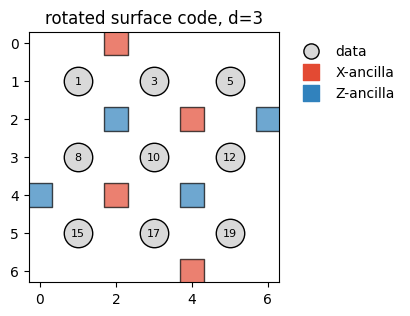

9 data, 4 X-ancillas, 4 Z-ancillas


In [2]:
s = ts._parse_schedule(3)

fig, ax = plt.subplots(figsize=(4.2, 4.2))
for q, (x, y) in s.coords.items():
    if q in s.data:
        ax.scatter(x, y, s=420, c="#d9d9d9", edgecolors="k", zorder=3)
        ax.text(x, y, str(q), ha="center", va="center", fontsize=8, zorder=4)
    elif q in s.x_anc:
        ax.scatter(x, y, s=300, marker="s", c="#e34a33", edgecolors="k", alpha=.7, zorder=2)
    else:
        ax.scatter(x, y, s=300, marker="s", c="#3182bd", edgecolors="k", alpha=.7, zorder=2)
ax.scatter([], [], s=120, c="#d9d9d9", edgecolors="k", label="data")
ax.scatter([], [], marker="s", s=120, c="#e34a33", label="X-ancilla")
ax.scatter([], [], marker="s", s=120, c="#3182bd", label="Z-ancilla")
ax.set_title("rotated surface code, d=3"); ax.set_aspect("equal")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
ax.invert_yaxis(); plt.tight_layout(); plt.show()

print(f"{len(s.data)} data, {len(s.x_anc)} X-ancillas, {len(s.z_anc)} Z-ancillas")

With **no noise** every detector must stay silent — a built-in correctness
check we use throughout. Turn noise on and detectors start to fire: these
*detection events* are what the decoder consumes.

In [3]:
clean = ts.memory_circuit(distance=3, rounds=3, basis="Z", p=0.0)
ts.assert_deterministic(clean)
print("zero noise: all detectors silent  OK")

noisy = ts.memory_circuit(distance=3, rounds=3, basis="Z", p=0.02)
res = ts.run_experiment(noisy, shots=8)
print(f"\n{res.detectors.shape[1]} detectors; detection events in 8 example shots:")
for i, row in enumerate(res.detectors):
    fired = np.where(row)[0].tolist()
    print(f"  shot {i}: {'(none)' if not fired else fired}")

zero noise: all detectors silent  OK



24 detectors; detection events in 8 example shots:
  shot 0: [2, 10, 12, 17]
  shot 1: [17, 22, 23]
  shot 2: [6, 9, 13, 18, 22]
  shot 3: [4, 9, 14, 17, 22]
  shot 4: [8, 16]
  shot 5: [1, 5, 6, 17, 18]
  shot 6: [2, 9]
  shot 7: [0, 1, 2]


## §2 — The decoder: detector-error model → PyMatching

The decoder's job: from the detection events, infer the most likely correction
and decide whether the *logical* observable was flipped. tsim (like Stim) can
compile a **detector-error model** (DEM) — the list of independent fault
mechanisms, each flipping a small set of detectors and possibly the logical
observable, with a probability. For our phenomenological noise every mechanism
flips at most two detectors, so the DEM is a graph and **minimum-weight perfect
matching** (PyMatching) is exact and fast.

`run_experiment` wires it together: tsim samples $(\text{detectors},
\text{observable})$, PyMatching predicts the logical flip from the detectors, and
a *logical error* is a shot where the prediction disagrees with the truth.

In [4]:
p = 0.006   # comfortably below threshold, where the decoder shines
circ = ts.memory_circuit(3, 3, "Z", p=p)
res = ts.run_experiment(circ, shots=20000)
pL, se = ts.wilson_interval(res.num_logical_errors, res.shots)
raw = np.mean(res.observables[:, 0] != 0)   # logical flips with NO decoding
print(f"d=3, p={p}, {res.shots} shots")
print(f"  raw logical-flip rate (no decoder): {raw:.4f}")
print(f"  decoded logical error rate p_L    : {pL:.4f} +/- {se:.4f}")
print(f"  -> the decoder removes ~{raw/pL:.1f}x of the failures")

d=3, p=0.006, 20000 shots
  raw logical-flip rate (no decoder): 0.1181
  decoded logical error rate p_L    : 0.0237 +/- 0.0011
  -> the decoder removes ~5.0x of the failures


**Demo A — one shot, end to end.** We pick a shot the decoder *corrects*
and print its detection events, the observable it read, and the flip PyMatching
predicted, so the pipeline is concrete rather than abstract.

In [5]:
m = ts._matching_from_circuit(circ)
res = ts.run_experiment(circ, shots=2000, matching=m)
# find a shot with detection events that was decoded correctly
idx = next(i for i in range(res.shots)
           if res.detectors[i].any() and not res.logical_errors[i])
print(f"shot {idx}")
print("  detection events at detectors:", list(np.where(res.detectors[idx])[0]))
print("  observable read from data    :", int(res.observables[idx, 0]))
print("  logical flip predicted        :", int(res.predictions[idx, 0]))
print("  corrected -> logical error?   :", bool(res.logical_errors[idx]))

shot 0
  detection events at detectors: [np.int64(15), np.int64(18), np.int64(19)]
  observable read from data    : 0
  logical flip predicted        : 0
  corrected -> logical error?   : False


## §3 — Two logical qubits and a transversal CNOT

Two patches sit **side-by-side** with disjoint qubit indices (never interleaved —
the layout convention from the MPS notebooks, which keeps the non-locality of an
inter-patch gate visible rather than hiding it). A **transversal CNOT** is a
physical CX between each data qubit of the control patch and the matching data
qubit of the target patch.

The subtle part is the **detectors across the CNOT**. From round $\geq 1$ both
stabiliser types are deterministic. A transversal CX (control $A$, target $B$)
conjugates the physical checks as

$$X_A \to X_A X_B,\qquad Z_B \to Z_A Z_B,\qquad X_B\to X_B,\qquad Z_A\to Z_A,$$

so at the first round *after* the CNOT the control patch's $X$-plaquette and the
target patch's $Z$-plaquette each pick up the same-location plaquette on the
other patch. Everything else is the ordinary "compare to previous round". We do
not trust this by argument — we **verify** it: under zero noise every detector,
including the ones straddling the CNOT, must stay silent.

Preparing $A$ in $|+\rangle_L$ and $B$ in $|0\rangle_L$ and applying
$\mathrm{CNOT}(A\to B)$ makes the logical **Bell** state
$(|00\rangle_L+|11\rangle_L)/\sqrt2$. Its signature: each logical qubit alone is
random, but the joint correlations $\langle Z_AZ_B\rangle$ and
$\langle X_AX_B\rangle$ are both $+1$.

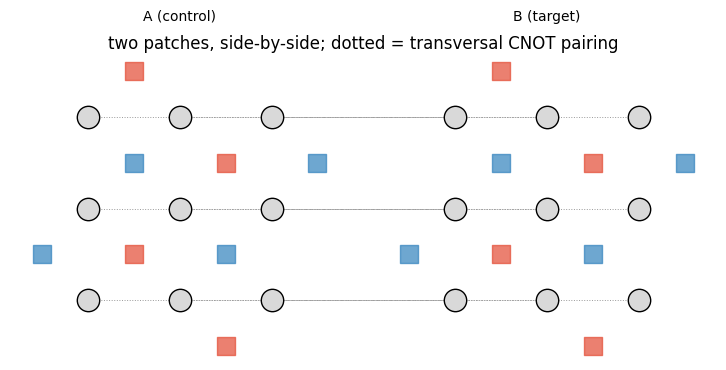

In [6]:
A = ts.Patch(s, 0, 0.0); B = ts.Patch(s, 1000, 2*3+2)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for P, name in ((A, "A (control)"), (B, "B (target)")):
    for q in P.data:  x, y = P.coords[q]; ax.scatter(x, y, s=260, c="#d9d9d9", edgecolors="k", zorder=3)
    for q in P.x_anc: x, y = P.coords[q]; ax.scatter(x, y, s=170, marker="s", c="#e34a33", alpha=.7)
    for q in P.z_anc: x, y = P.coords[q]; ax.scatter(x, y, s=170, marker="s", c="#3182bd", alpha=.7)
    cx = np.mean([P.coords[q][0] for q in P.data]); ax.text(cx, -1.1, name, ha="center", fontsize=10)
# draw the transversal CX pairing
for loc, qa in A.data_by_loc.items():
    qb = B.data_by_loc[loc]
    (x0, y0), (x1, y1) = A.coords[qa], B.coords[qb]
    ax.plot([x0, x1], [y0, y1], color="0.6", lw=.7, ls=":", zorder=1)
ax.set_title("two patches, side-by-side; dotted = transversal CNOT pairing")
ax.set_aspect("equal"); ax.invert_yaxis(); ax.axis("off"); plt.tight_layout(); plt.show()

In [7]:
for basis in ("Z", "X"):
    txt, _ = ts.two_patch_circuit(prepA="X", prepB="Z", meas_basis=basis, p=0.0)
    ts.assert_deterministic(txt)
print("Bell circuit, zero noise: every detector silent (cross-CNOT rule verified)  OK\n")

zz = ts.sample_correlator(ts.two_patch_circuit(prepA="X", prepB="Z", meas_basis="Z", p=0.0)[0],
                          shots=40000, decode=False)
xx = ts.sample_correlator(ts.two_patch_circuit(prepA="X", prepB="Z", meas_basis="X", p=0.0)[0],
                          shots=40000, decode=False)
print(f"logical Bell state:  <ZZ> = {zz:+.3f}   <XX> = {xx:+.3f}   (ideal +1 / +1)")

Bell circuit, zero noise: every detector silent (cross-CNOT rule verified)  OK



logical Bell state:  <ZZ> = +1.000   <XX> = +1.000   (ideal +1 / +1)


## §4 — The non-Clifford $T$ and magic states

Universal computation needs a non-Clifford gate. The magic-Bell circuit
$H\cdot T\cdot\mathrm{CNOT}$ — $|0\rangle|0\rangle \to$ H on $q_0 \to$ T on
$q_0 \to \mathrm{CNOT}(q_0\to q_1)$ — produces
$(|00\rangle+e^{i\pi/4}|11\rangle)/\sqrt2$, whose correlators are the fingerprint
of a genuine $T$:

$$\langle Z_AZ_B\rangle = 1,\qquad \langle X_AX_B\rangle=\cos(\tfrac{\pi}{4})=0.707.$$

We build it three ways, increasing in honesty.

**§4a — the bare-qubit shortcut.** Strip the code away and run
$H\cdot T\cdot\mathrm{CNOT}$ on two *physical* qubits. This isolates tsim's
non-Clifford ability — Stim could not run this line at all — and reproduces
$0.707$ exactly. It is a capability demo, **not** fault-tolerant.

In [8]:
bare = ("R 0 1\nH 0\nT 0\nCX 0 1\n"       # H . T . CNOT
        "H 0 1\nM 0 1\n"                       # measure both in X
        "OBSERVABLE_INCLUDE(0) rec[-2]\nOBSERVABLE_INCLUDE(1) rec[-1]")
xx = ts.sample_correlator(bare, shots=100000, decode=False)
print(f"bare-qubit magic Bell:  <XX> = {xx:+.3f}   (ideal 0.707)")

bare-qubit magic Bell:  <XX> = +0.710   (ideal 0.707)


**§4b — the tempting *wrong* way on the code.** Since tsim takes a $T$,
why not just apply $T$ to the data qubits carrying the logical-$X$ string? Because
$T$ does not commute with the $X$-stabilisers it touches: it corrupts the code.
The check below shows detectors firing under **zero** noise (the state has left
the code space) and the correlator landing at the wrong value.

In [9]:
wrong, _ = ts.two_patch_circuit(prepA="X", prepB="Z", meas_basis="X", naive_t=True, p=0.0)
tc = tsim.Circuit(wrong)
det, _ = tc.compile_detector_sampler().sample(shots=512, separate_observables=True)
n_bad = int(np.asarray(det).any(axis=0).sum())
xx = ts.sample_correlator(wrong, shots=40000, decode=False)
print(f"naive T on the logical string:")
print(f"  detectors firing at ZERO noise: {n_bad}  (code space broken)")
print(f"  <XX> = {xx:+.3f}   (should be 0.707 -- it is not)")

naive T on the logical string:
  detectors firing at ZERO noise: 2  (code space broken)
  <XX> = +0.350   (should be 0.707 -- it is not)


**§4c — the honest way: magic-state injection.** A logical $T$ on a 2D
surface code is *not* transversal, so we do not apply it directly. Instead we
**inject** the magic state $|A\rangle_L = T|+\rangle_L$: prepare $|+\rangle_L$ and
apply a single physical $T$ to the code's corner qubit (the site shared by the
logical-$X$ and logical-$Z$ strings). A round of stabiliser measurement then
projects it into the encoded $|A\rangle_L$. The transversal CNOT into
$|0\rangle_L$ completes $H\cdot T\cdot\mathrm{CNOT}$ on the encoded qubits — and
now the whole thing is a valid codeword, so it stays deterministic under zero
noise and **decodes** under noise.

In [10]:
for basis in ("Z", "X"):
    txt, _ = ts.two_patch_circuit(prepA="A", prepB="Z", meas_basis=basis, p=0.0)
    ts.assert_deterministic(txt)
print("encoded magic-Bell, zero noise: deterministic  OK\n")

zz = ts.sample_correlator(ts.two_patch_circuit(prepA="A", prepB="Z", meas_basis="Z", p=0.0)[0],
                          shots=40000, decode=False)
xx = ts.sample_correlator(ts.two_patch_circuit(prepA="A", prepB="Z", meas_basis="X", p=0.0)[0],
                          shots=40000, decode=False)
print(f"encoded magic Bell:  <ZZ> = {zz:+.3f}   <XX> = {xx:+.3f}   (ideal 1.000 / 0.707)")

encoded magic-Bell, zero noise: deterministic  OK



encoded magic Bell:  <ZZ> = +1.000   <XX> = +0.708   (ideal 1.000 / 0.707)


Under noise the decoder earns its keep: it removes the *error-induced*
logical flips, leaving the intrinsic $0.707$ quantum correlation of the $T$
gate. As $p$ rises, uncorrected faults wash the correlations out — the onset of
logical failure on a genuinely non-Clifford circuit.

In [11]:
print(f"{'p':>7}  {'<ZZ> decoded':>13}  {'<XX> decoded':>13}")
for p in (0.0, 0.005, 0.01, 0.02, 0.04):
    zz = ts.sample_correlator(ts.two_patch_circuit(prepA="A", prepB="Z", meas_basis="Z", p=p)[0],
                              shots=30000, decode=True)
    xx = ts.sample_correlator(ts.two_patch_circuit(prepA="A", prepB="Z", meas_basis="X", p=p)[0],
                              shots=30000, decode=True)
    print(f"{p:>7}  {zz:>13.3f}  {xx:>13.3f}")
print("\n(ideal at p=0: 1.000 / 0.707)")

      p   <ZZ> decoded   <XX> decoded


    0.0          1.000          0.702


  0.005          0.985          0.675


   0.01          0.952          0.621


   0.02          0.855          0.525


   0.04          0.592          0.324

(ideal at p=0: 1.000 / 0.707)


## §5 — Decoding strategy: whole circuit vs the sliding window

Notebook 6 built a **real-time sliding-window** decoder: it commits corrections
on a trailing window as syndrome streams in, because a real machine cannot wait
until the end of a long computation to decode. tsim takes the opposite, offline
stance that suits a *sampling* study: it compiles **one** detector-error model
for the entire circuit and PyMatching matches the whole space-time graph at once.

| | notebook 6 sliding window (MPS) | tsim + PyMatching (here) |
|---|---|---|
| When | online, as rounds arrive | offline, whole shot at once |
| Graph | overlapping windows, artificial defects | one global DEM |
| Good for | latency, feed-forward $T$ commitment | throughput, $p_L$ statistics |

They are complementary: sliding-window is about *when* you can act on a
correction; the global match is about decoding millions of shots cheaply to
measure a rate. The DEM below is exactly the space-time matching graph — its size
is what a windowed decoder would chunk.

In [12]:
dem = ts.memory_circuit(5, 5, "Z", p=0.01).detector_error_model(decompose_errors=True)
print(f"d=5, R=5 memory DEM: {dem.num_detectors} detectors, "
      f"{dem.num_observables} observable, {dem.num_errors} fault mechanisms")

d=5, R=5 memory DEM: 120 detectors, 1 observable, 1953 fault mechanisms


## §6 — Noise and the threshold crossing — what the MPS could not show

The headline QEC plot: sweep the physical error rate $p$ and watch the logical
rate $p_L$ for several distances. **Below threshold** a larger code suppresses
$p_L$ (more distance = more protection); **above threshold** more qubits only add
more ways to fail, so the curves *cross*. The crossing point is the threshold.

Notebook 7 was pinned at $d=3$ and could only show $p_L$ rising with $p$. Because
tsim samples cheaply and Stim gives the geometry at any $d$, we can run $d=3,5,7$
and actually see the curves cross — the qualitative payoff of moving off the exact
engine.

In [13]:
ps = np.array([0.002, 0.004, 0.006, 0.009, 0.013, 0.02])
dists = [3, 5, 7]
shots = 20000
curves = {}
for d in dists:
    pL = []
    for p in ps:
        c = ts.memory_circuit(d, rounds=d, basis="Z", p=p)
        est, _ = ts.estimate_pL(c, shots=shots)
        pL.append(est)
    curves[d] = np.array(pL)
    print(f"d={d}: p_L = " + "  ".join(f"{v:.3f}" for v in pL))

d=3: p_L = 0.003  0.012  0.024  0.055  0.090  0.172


d=5: p_L = 0.001  0.007  0.023  0.065  0.147  0.298


d=7: p_L = 0.000  0.004  0.021  0.076  0.200  0.406


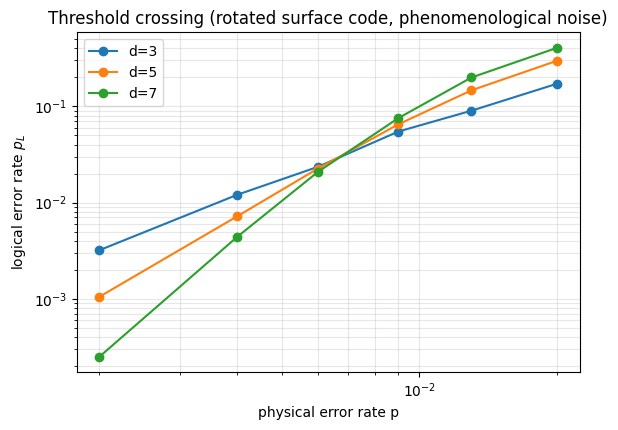

d=7 below d=3 up to p~0.006, above it beyond p~0.009
  -> threshold p_th is between 0.006 and 0.009


In [14]:
fig, ax = plt.subplots(figsize=(6, 4.4))
for d in dists:
    ax.plot(ps, curves[d], "o-", label=f"d={d}")
ax.set_xlabel("physical error rate p"); ax.set_ylabel(r"logical error rate $p_L$")
ax.set_yscale("log"); ax.set_xscale("log")
ax.set_title("Threshold crossing (rotated surface code, phenomenological noise)")
ax.legend(); ax.grid(True, which="both", alpha=.3); plt.tight_layout(); plt.show()

# the threshold is where the d=3 and d=7 curves cross: d=7 helps below, hurts above
diff = curves[7] - curves[3]          # negative => larger code wins (below threshold)
sign = np.sign(diff)
cross = np.where(np.diff(sign) > 0)[0]  # - to + transition
if len(cross):
    i = cross[0]
    print(f"d=7 below d=3 up to p~{ps[i]:.3f}, above it beyond p~{ps[i+1]:.3f}")
    print(f"  -> threshold p_th is between {ps[i]:.3f} and {ps[i+1]:.3f}")
else:
    print("no crossing in this range")

## §7 — What this notebook establishes

* A full surface-code QEC stack on **tsim**: geometry and schedule from Stim,
  **native $T$**, sampling in tsim, and **MWPM decoding** with PyMatching —
  the same decoding principle as the ITensor series, on a sampling engine.
* A **single logical qubit** memory (§1) and its **decoder** (§2), with the
  decoder removing the large majority of failures.
* **Two logical qubits** entangled by a **transversal CNOT** (§3), with the
  cross-CNOT detectors derived from CSS stabiliser flow and *verified* by
  zero-noise determinism, reproducing $\langle ZZ\rangle=\langle XX\rangle=1$.
* The **non-Clifford $T$** three ways (§4): the bare-qubit shortcut ($0.707$
  exactly), the instructive *wrong* way (broken code space), and honest
  **magic-state injection** giving the encoded magic-Bell that **decodes** under
  noise.
* The **threshold crossing** across $d=3,5,7$ (§6) — the plot the exact MPS
  engine at fixed $d=3$ could not produce.

**What it does *not* capture** (where the exact MPS engine wins): no exact
non-collapsing expectation values (everything is Monte-Carlo), the injected magic
state is a physical (non-distilled, non-fault-tolerant) input, and the noise here
is phenomenological rather than a full circuit-level model with hook errors.

The companion notebook **`example_tsim_vs_itensor.ipynb`** puts the two engines
head to head on the 2-qubit magic-Bell circuit: do their $p_L$ agree, how does
throughput compare, and how does each scale with distance and $T$-count?